In [2]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Synthetic polygons

In [3]:
import sys 
from src.mask_utils import add_features_to_coco, find_main_polygon_orientations
from src.visualization import show_angle_orientation
import importlib
importlib.reload(sys.modules['src.orientation_metrics'])
importlib.reload(sys.modules['src.visualization'])
importlib.reload(sys.modules['src.mask_utils'])
from src.mask_utils import add_features_to_coco, find_main_polygon_orientations
from src.visualization import show_angle_orientation
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import json 
import cv2


from src.synthetic_data import generate_segments_coco

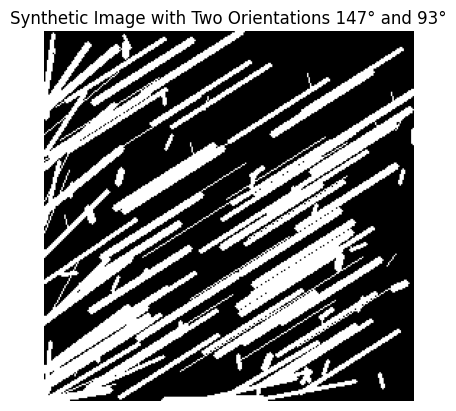

True

In [5]:
or1 = np.random.randint(0, 180)
or2 = np.random.randint(0, 180)

# First and Second synthtetic orientation
img1, ann1 = generate_segments_coco(img_size=256, num_segments=100, main_angle_deg=or1, angle_std_deg=0, length_range=(80, 81), image_id=1)
img2, ann2 = generate_segments_coco(img_size=256, num_segments=50, main_angle_deg=or2, angle_std_deg=25, length_range=(10, 11), base_image=img1, image_id=1, annotation_start_id=len(ann1)+1)

# Combine annotations
all_annotations = ann1 + ann2
img = img2[:,:,0]
title_synthetic_image = f'Synthetic Image with Two Orientations {or1}° and {or2}°'

# all_annotations = ann1 
# img2 = img1.copy()
# img = img2[:,:,0]
# title_synthetic_image = f'Synthetic Image with One Orientation {or1}° '

#
# COCO format
synthetic_coco_output = {
    "images": [
        {"id": 1, "width": 256, "height": 256, "file_name": "synthetic.jpg"}
    ],
    "annotations": all_annotations,
    "categories": [{"id": 1, "name": "line"}]
}

# Save JSON
with open("synthetic_coco.json", "w") as f:
    json.dump(synthetic_coco_output, f, indent=4)

# Display image



plt.figure()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(title_synthetic_image)
plt.show()
cv2.imwrite(r"C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features\GT_imagessynthetic.jpg", img)


In [6]:
from src.mask_utils import add_features_to_coco, find_main_polygon_orientations
from src.visualization import show_angle_orientation
from src.orientation_metrics import find_main_orientation


base_path = r'C:\Users\lud44009\Documents\Projects\20240513 - A.Cherchari\PBC\data\annotations_filtered_artifacts\test'
json_path = r"synthetic_coco.json"
image_folder = os.path.join(base_path, 'images')

with open(json_path, "r") as f:
    coco_data = json.load(f)

Processing annotations:   0%|          | 0/150 [00:00<?, ?it/s]

Processing annotations: 100%|██████████| 150/150 [00:00<00:00, 303.17it/s]


Dominant Image Orientations (degrees): [0]


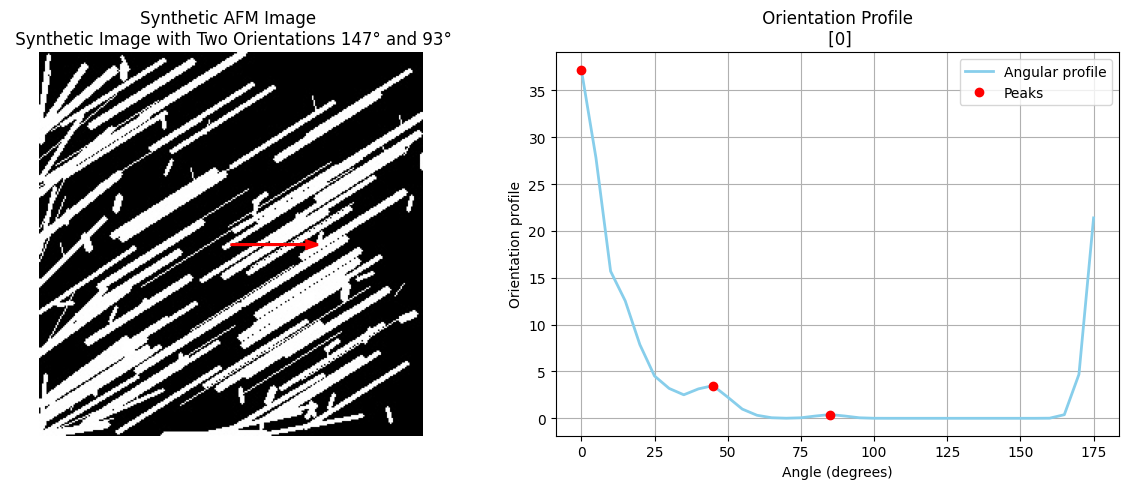

In [7]:
# add orientations in the coco json annotation file
# convention is 0 to 180 pointing downwards from right to left
updated_coco = add_features_to_coco(coco_data)

image_id = 1
image_entry = next((img for img in updated_coco["images"] if img["id"] == image_id), None)
synthetic_image = r"C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features\GT_imagessynthetic.jpg"
img = plt.imread(synthetic_image)


# --- Polygon orientation analysis ---
hist_smoothed, peaks, angle_bins = find_main_polygon_orientations(
    updated_coco, image_id
)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, hist_smoothed)


# --- VISUALIZATION ---
# Use the same show_angle_orientation than fft plot
print("Dominant Image Orientations (degrees):", np.round(dominant_image_orientations, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: show image with orientation arrows
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red', 'blue'], arrow_length=50)
ax[0].set_title(f'Synthetic AFM Image \n {title_synthetic_image}')

# Right: angular profile with peaks
ax[1].plot(angle_bins[:-1], hist_smoothed, label='Angular profile', color='skyblue', linewidth=2)
ax[1].plot(angle_bins[peaks], hist_smoothed[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Orientation profile")
ax[1].set_title(f" Orientation Profile \n {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

Processing annotations: 100%|██████████| 150/150 [00:00<00:00, 305.97it/s]


Dominant Image Orientations (degrees): [0]


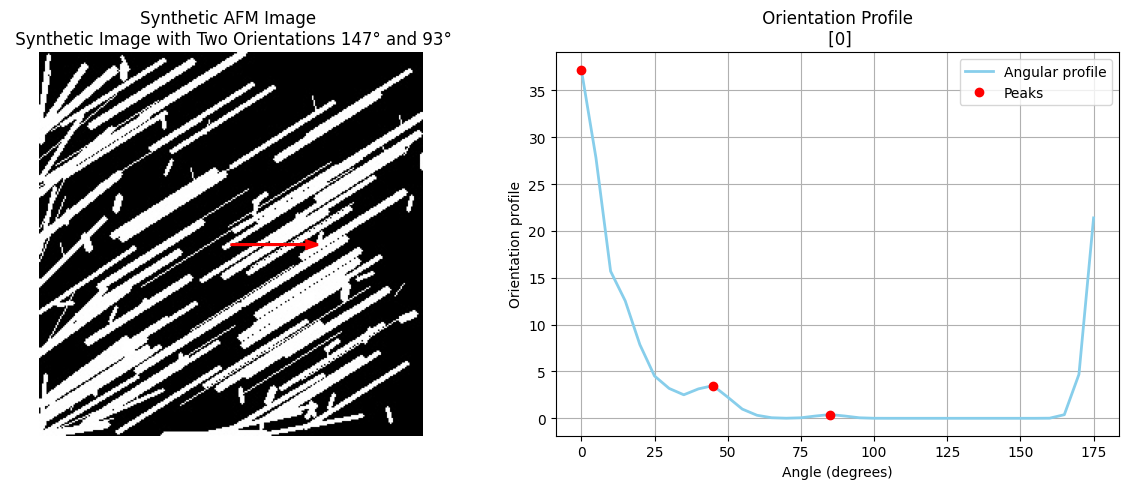

In [8]:
# add orientations in the coco json annotation file
# convention is 0 to 180 pointing downwards from right to left
updated_coco = add_features_to_coco(coco_data)

image_id = 1
image_entry = next((img for img in updated_coco["images"] if img["id"] == image_id), None)
synthetic_image = r"C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features\GT_imagessynthetic.jpg"
img = plt.imread(synthetic_image)


# --- Polygon orientation analysis ---
hist_smoothed, peaks, angle_bins = find_main_polygon_orientations(
    updated_coco, image_id
)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, hist_smoothed)


# --- VISUALIZATION ---
# Use the same show_angle_orientation than fft plot
print("Dominant Image Orientations (degrees):", np.round(dominant_image_orientations, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: show image with orientation arrows
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red', 'blue'], arrow_length=50)
ax[0].set_title(f'Synthetic AFM Image \n {title_synthetic_image}')

# Right: angular profile with peaks
ax[1].plot(angle_bins[:-1], hist_smoothed, label='Angular profile', color='skyblue', linewidth=2)
ax[1].plot(angle_bins[peaks], hist_smoothed[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Orientation profile")
ax[1].set_title(f" Orientation Profile \n {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

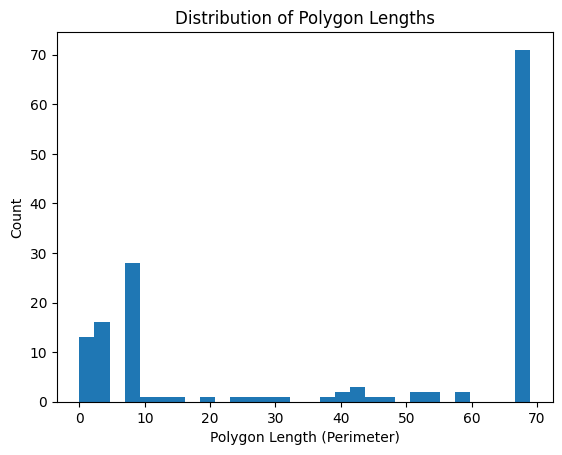

In [9]:
def extract_polygon_lengths(coco_data):
    """
    Extract the 'length' field from each annotation in the COCO file.
    Returns a list of length values.
    """
    lengths = []

    for ann in coco_data.get("annotations", []):
        if "length" in ann:
            lengths.append(ann["length"])

    return lengths


lengths = extract_polygon_lengths(updated_coco)


plt.hist(lengths, bins=30)
plt.xlabel("Polygon Length (Perimeter)")
plt.ylabel("Count")
plt.title("Distribution of Polygon Lengths")
plt.show()

# Prediction data

In [10]:
base_path = r'C:\Users\abd93000\PycharmProjects\cnt_project_v2\testing\data\annotations_uniques\test'
json_path = os.path.join(base_path, 'COCO_mask', 'predicted_annotations.json' )
image_folder = os.path.join(base_path, 'images')

with open(json_path, "r") as f:
    coco_data = json.load(f)


Processing annotations: 100%|██████████| 4256/4256 [00:16<00:00, 265.38it/s]

Dominant Image Orientations (degrees): [5]


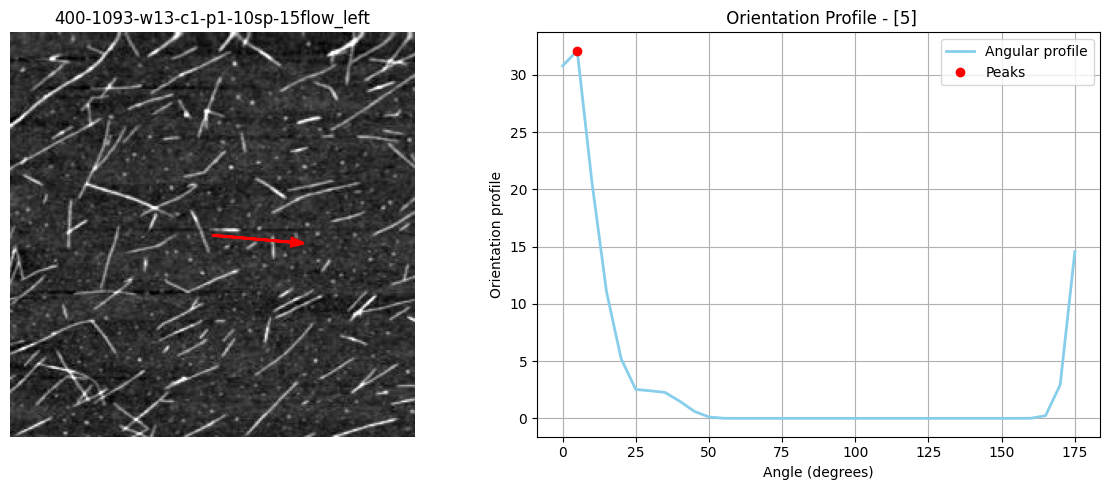

In [11]:
updated_coco = add_features_to_coupdated_coco = add_features_to_coco(coco_data)


image_id = np.random.choice(len(updated_coco['images']))
image_entry = next((img for img in updated_coco["images"] if img["id"] == image_id), None)
title_real_image = image_entry['file_name']

img = plt.imread(os.path.join(base_path, 'images', title_real_image + '.jpg'))[:,:,0]

# --- Polygon orientation analysis ---
hist_smoothed, peaks, angle_bins = find_main_polygon_orientations(
    updated_coco, image_id
)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, hist_smoothed)


# --- VISUALIZATION ---
# Use the same show_angle_orientation than fft plot
print("Dominant Image Orientations (degrees):", np.round(dominant_image_orientations, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: show image with orientation arrows
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red', 'blue'], arrow_length=50)
ax[0].set_title(title_real_image)

# Right: angular profile with peaks
ax[1].plot(angle_bins[:-1], hist_smoothed, label='Angular profile', color='skyblue', linewidth=2)
ax[1].plot(angle_bins[peaks], hist_smoothed[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Orientation profile")
ax[1].set_title(f" Orientation Profile - {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

Processing annotations: 100%|██████████| 4256/4256 [00:15<00:00, 276.71it/s]


Dominant Image Orientations (degrees): [5]


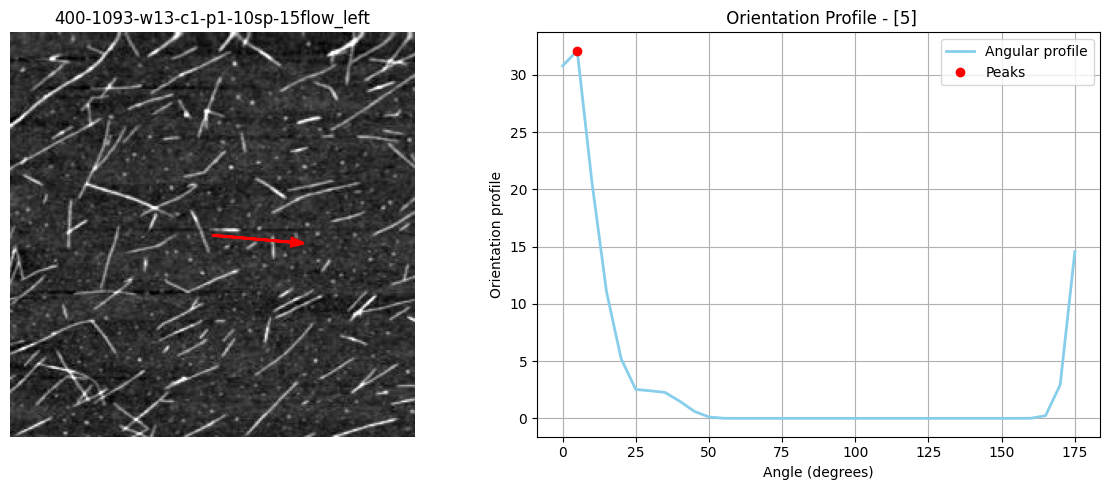

In [12]:
updated_coco = add_features_to_coupdated_coco = add_features_to_coco(coco_data)


image_id = np.random.choice(len(updated_coco['images']))
image_entry = next((img for img in updated_coco["images"] if img["id"] == image_id), None)
title_real_image = image_entry['file_name']

img = plt.imread(os.path.join(base_path, 'images', title_real_image + '.jpg'))[:,:,0]

# --- Polygon orientation analysis ---
hist_smoothed, peaks, angle_bins = find_main_polygon_orientations(
    updated_coco, image_id
)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, hist_smoothed)


# --- VISUALIZATION ---
# Use the same show_angle_orientation than fft plot
print("Dominant Image Orientations (degrees):", np.round(dominant_image_orientations, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: show image with orientation arrows
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red', 'blue'], arrow_length=50)
ax[0].set_title(title_real_image)

# Right: angular profile with peaks
ax[1].plot(angle_bins[:-1], hist_smoothed, label='Angular profile', color='skyblue', linewidth=2)
ax[1].plot(angle_bins[peaks], hist_smoothed[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Orientation profile")
ax[1].set_title(f" Orientation Profile - {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

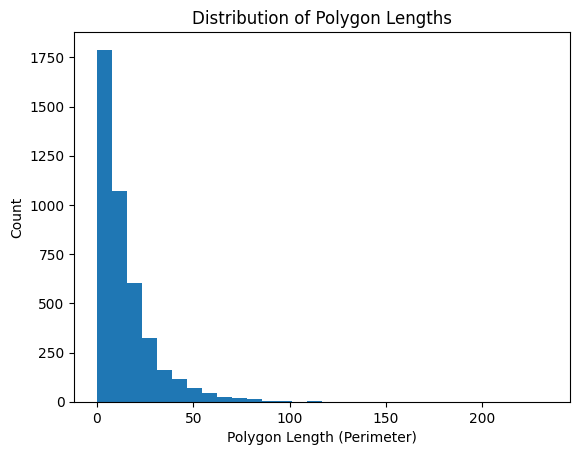

In [13]:
def extract_polygon_lengths(coco_data):
    """
    Extract the 'length' field from each annotation in the COCO file.
    Returns a list of length values.
    """
    lengths = []

    for ann in coco_data.get("annotations", []):
        if "length" in ann:
            lengths.append(ann["length"])

    return lengths


lengths = extract_polygon_lengths(updated_coco)


plt.hist(lengths, bins=30)
plt.xlabel("Polygon Length (Perimeter)")
plt.ylabel("Count")
plt.title("Distribution of Polygon Lengths")
plt.show()


# groundtruth data

In [14]:
# base_path = r'C:\Users\lud44009\Documents\Projects\20240513 - A.Cherchari\PBC\data\annotations_filtered_artifacts\test'
json_path = os.path.join(base_path, 'COCO_mask', 'annotations.json' )
image_folder = os.path.join(base_path, 'images')

with open(json_path, "r") as f:
    coco_data = json.load(f)

Processing annotations: 100%|██████████| 2906/2906 [00:09<00:00, 298.21it/s]


Dominant Image Orientations (degrees): [0]


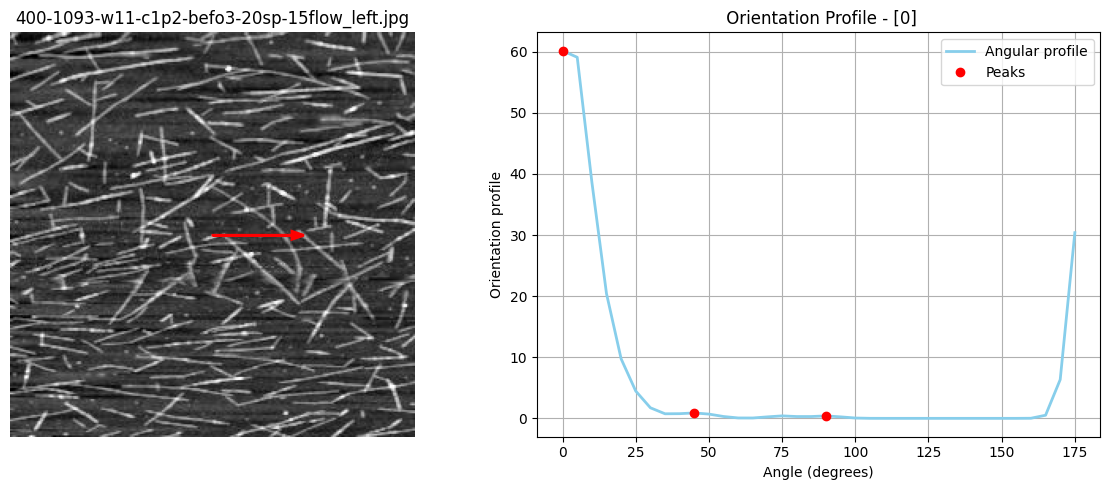

In [15]:
updated_coco = add_features_to_coco(coco_data)


image_id = np.random.choice(len(updated_coco['images']))
image_id = 3
image_entry = next((img for img in updated_coco["images"] if img["id"] == image_id), None)
title_real_image = image_entry['file_name']

img = plt.imread(os.path.join(base_path, 'images', title_real_image ))[:,:,0]

# --- Polygon orientation analysis ---
hist_smoothed, peaks, angle_bins = find_main_polygon_orientations(
    updated_coco, image_id
)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, hist_smoothed)

# --- VISUALIZATION ---
# Use the same show_angle_orientation than fft plot
print("Dominant Image Orientations (degrees):", np.round(dominant_image_orientations, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: show image with orientation arrows
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red', 'blue'], arrow_length=50)
ax[0].set_title(title_real_image)

# Right: angular profile with peaks
ax[1].plot(angle_bins[:-1], hist_smoothed, label='Angular profile', color='skyblue', linewidth=2)
ax[1].plot(angle_bins[peaks], hist_smoothed[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Orientation profile")
ax[1].set_title(f" Orientation Profile - {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

# Run through all images

In [18]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_path = r'C:\Users\abd93000\PycharmProjects\cnt_project_v2\testing\data\annotations_uniques\test'
save_output = r'C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features\polygon_analysis_prediction'
json_path = os.path.join(base_path, 'COCO_mask', 'predicted_annotations 2.json' )
# save_output = r'C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features\polygon_analysis_groundtruth'
# json_path = os.path.join(base_path, 'COCO_mask', 'annotations.json' )
selected_folder = os.path.join(base_path, 'images')




with open(json_path, "r") as f:
    coco_data = json.load(f)

# --- Main batch processing for polygon orientation extraction ---

# Assuming you already have your updated COCO dictionary
# (after running add_features_to_coco)
updated_coco = add_features_to_coco(coco_data)

# Paths
os.makedirs(save_output, exist_ok=True)

orientation_list = []

# Loop through each image entry in the COCO dataset
for image_entry in updated_coco["images"]:
    image_id = image_entry["id"]
    image_filename = image_entry["file_name"]
    #image_path = os.path.join(base_path, "images", image_filename +'.jpg' )

    # WARNING
    # due to 2 different file_name conventions
    # uncomment if running groundtruth json
    # do not update the groundtruth_json before discussing the whole algorithm
    image_path = os.path.join(base_path, "images", image_filename  ) 

    # Read image (grayscale)
    img = plt.imread(image_path)
    if img.ndim == 3:
        img = img[:, :, 0]

    # --- Polygon orientation analysis ---
    hist_smoothed, peaks, angle_bins = find_main_polygon_orientations(
        updated_coco, image_id
    )
    dominant_image_orientations = find_main_orientation(peaks, angle_bins, hist_smoothed)

    print(f"{image_filename} → Dominant polygon orientations: {dominant_image_orientations}")

    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Left: image visualization with polygon orientations
    title_real_image = f"Polygon Mask Image: {image_filename}"
    show_angle_orientation(
        ax[0], img, dominant_image_orientations,
        colors=['r', 'b', 'g', 'y', 'm'], arrow_length=50
    )
    ax[0].set_title(title_real_image)

    # Right: orientation histogram with peaks
    ax[1].plot(angle_bins[:-1], hist_smoothed, label="Orientation histogram (smoothed)")
    ax[1].plot(angle_bins[peaks], hist_smoothed[peaks], "ro", label="Detected peaks")
    ax[1].set_xlabel("Angle (degrees)")
    ax[1].set_ylabel("Polygon count / weight")
    ax[1].set_title(f"Polygon Orientation Distribution\n{dominant_image_orientations}")
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout()

    # --- Save figure ---
    save_fig_path = os.path.join(save_output, image_filename + "_polygon_orientations.png")
    fig.savefig(save_fig_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    # --- Store results ---
    ori_padded = np.full(2, np.nan)
    ori_padded[:len(dominant_image_orientations)] = dominant_image_orientations[:2]

    orientation_list.append({
        # WARNING
        # due to 2 different file_name conventions
        # uncomment if running groundtruth json
        # do not update the groundtruth_json before discussing the whole algorithm
        #"filename": image_filename + '.jpg',
        "filename": image_filename ,
        "orientation_1_deg": ori_padded[0],
        "orientation_2_deg": ori_padded[1],
    })

# --- Save results to CSV ---
df_orientations = pd.DataFrame(orientation_list)
csv_path = os.path.join(save_output, "polygon_orientations.csv")
df_orientations.to_csv(csv_path, index=False)

print(f"Saved polygon orientation summary → {csv_path}")



Processing annotations: 100%|██████████| 4256/4256 [00:15<00:00, 277.52it/s]


1293-22_3_2_20230306222551.jpg → Dominant polygon orientations: [0]
400-1093-w11-c1p1-befo3-10sp-15flow_left.jpg → Dominant polygon orientations: [0]
400-1093-w11-c1p2-befo3-20sp-15flow_left.jpg → Dominant polygon orientations: [0]
400-1093-w13-c1-p1-10sp-15flow_left.jpg → Dominant polygon orientations: [5]
400-1093-w16-c-1-p1-10sp-15flow_left.jpg → Dominant polygon orientations: [0]
400-1093-w17-c1p3-20sp-03flow_right.jpg → Dominant polygon orientations: [5]
400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right.jpg → Dominant polygon orientations: [5]
400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.jpg → Dominant polygon orientations: [0]
400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.jpg → Dominant polygon orientations: [10]
400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right.jpg → Dominant polygon orientations: [5]
400-1293-18_cd_c11k4r9_fl1_0sp9_image_right.jpg → Dominant polygon orientations: [5]
400-1293-18_cd_c1k1r3_fl0_3sp0_3_image_left.jpg → Dominant polygon orientations: [0]
400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_